In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv('dataset.csv')
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.shape)


(7043, 21)


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.tail()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# TotalCharges is in Object data type, making it numeric type
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# making test and train set
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes':1, 'No':0})

# the remaining categorical columns are strings, one-hot encode them so the
# models (and the distance maths in the custom KNN) get numeric input
X = pd.get_dummies(X, drop_first=True).astype(float)
print(X.shape)
X.head()

(7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,34.0,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,2.0,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,45.0,42.30,1840.75,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,151.65,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(5634, 30) (1409, 30)


In [11]:
class KNNFromScratch:
    def __init__(self, k=15):
        if k < 1:
            raise ValueError("k must be at least 1")
        self.k = k

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)
        if self.X_train.ndim != 2:
            raise ValueError("X must be a 2D array")
        if len(self.X_train) != len(self.y_train):
            raise ValueError("X and y must contain the same number of samples")
        self.n_neighbors = min(self.k, len(self.X_train))
        return self

    def predict_proba(self, X, batch_size=1000):
        if not hasattr(self, "X_train"):
            raise RuntimeError("Call fit before predict_proba")
        X = np.asarray(X, dtype=float)
        probs = np.zeros(len(X))

        for start in range(0, len(X), batch_size):
            X_batch = X[start:start + batch_size]
            dists = np.sqrt(np.maximum(
                np.sum(X_batch**2, axis=1, keepdims=True)
                + np.sum(self.X_train**2, axis=1)
                - 2 * np.dot(X_batch, self.X_train.T),
                0
            ))
            k_indices = np.argpartition(
                dists, self.n_neighbors - 1, axis=1
            )[:, :self.n_neighbors]
            probs[start:start + len(X_batch)] = np.mean(
                self.y_train[k_indices] == 1, axis=1
            )

        return probs

    def predict(self, X, batch_size=1000):
        return (self.predict_proba(X, batch_size) >= 0.5).astype(int)

print("Training Custom KNN Classifier from Scratch...")
knn_scratch = KNNFromScratch(k=15)
knn_scratch.fit(X_train_scaled, y_train)
knn_scratch_probs = knn_scratch.predict_proba(X_test_scaled)
knn_scratch_preds = knn_scratch.predict(X_test_scaled)

Training Custom KNN Classifier from Scratch...


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

searches = {
    "Decision Tree": GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 10],
            "min_samples_leaf": [1, 5]
        },
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1
    ),
    "SVM": GridSearchCV(
        SVC(probability=True, random_state=42),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]
        },
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1
    ),
    "MLP Neural Net": GridSearchCV(
        MLPClassifier(early_stopping=True, max_iter=300, random_state=42),
        {
            "hidden_layer_sizes": [(50,), (100,)],
            "alpha": [0.0001, 0.001],
            "learning_rate_init": [0.001, 0.01]
        },
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1
    )
}

best_models = {}
for name, search in searches.items():
    print(f"Tuning {name}...")
    search.fit(X_train_scaled, y_train)
    best_models[name] = search.best_estimator_
    print(f"{name} best parameters: {search.best_params_}")
    print(f"{name} best validation F1: {search.best_score_:.4f}")

models = {
    "Custom KNN": knn_scratch,
    "Decision Tree": best_models["Decision Tree"],
    "SVM": best_models["SVM"],
    "Naive Bayes": GaussianNB(),
    "MLP Neural Net": best_models["MLP Neural Net"]
}

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_scaled)
    model_probabilities = model.predict_proba(X_test_scaled)
    probabilities[name] = (
        model_probabilities
        if model_probabilities.ndim == 1
        else model_probabilities[:, 1]
    )

Tuning Decision Tree...
Decision Tree best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Decision Tree best validation F1: 0.5446
Tuning SVM...
SVM best parameters: {'C': 10, 'kernel': 'linear'}
SVM best validation F1: 0.5871
Tuning MLP Neural Net...
MLP Neural Net best parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}
MLP Neural Net best validation F1: 0.5786


Custom KNN train accuracy: 0.813 test accuracy: 0.769
Decision Tree train accuracy: 0.802 test accuracy: 0.794
SVM train accuracy: 0.8 test accuracy: 0.786
Naive Bayes train accuracy: 0.665 test accuracy: 0.656
MLP Neural Net train accuracy: 0.819 test accuracy: 0.793
Decision Tree cross-validation accuracy: 0.787
SVM cross-validation accuracy: 0.8
Naive Bayes cross-validation accuracy: 0.664
MLP Neural Net cross-validation accuracy: 0.799
=== CLASSIFIER EVALUATION COMPARISON ===
         Model  Accuracy  Precision  Recall  Specificity  F1-Score  Balanced Accuracy  ROC-AUC    MCC  Log Loss
    Custom KNN    0.7693     0.5694  0.5374       0.8531    0.5530             0.6953   0.8082 0.3980    0.6132
 Decision Tree    0.7942     0.6312  0.5401       0.8860    0.5821             0.7130   0.8267 0.4491    0.4552
           SVM    0.7864     0.6130  0.5294       0.8792    0.5681             0.7043   0.8238 0.4293    0.4431
   Naive Bayes    0.6558     0.4269  0.8663       0.5797    0.5719 

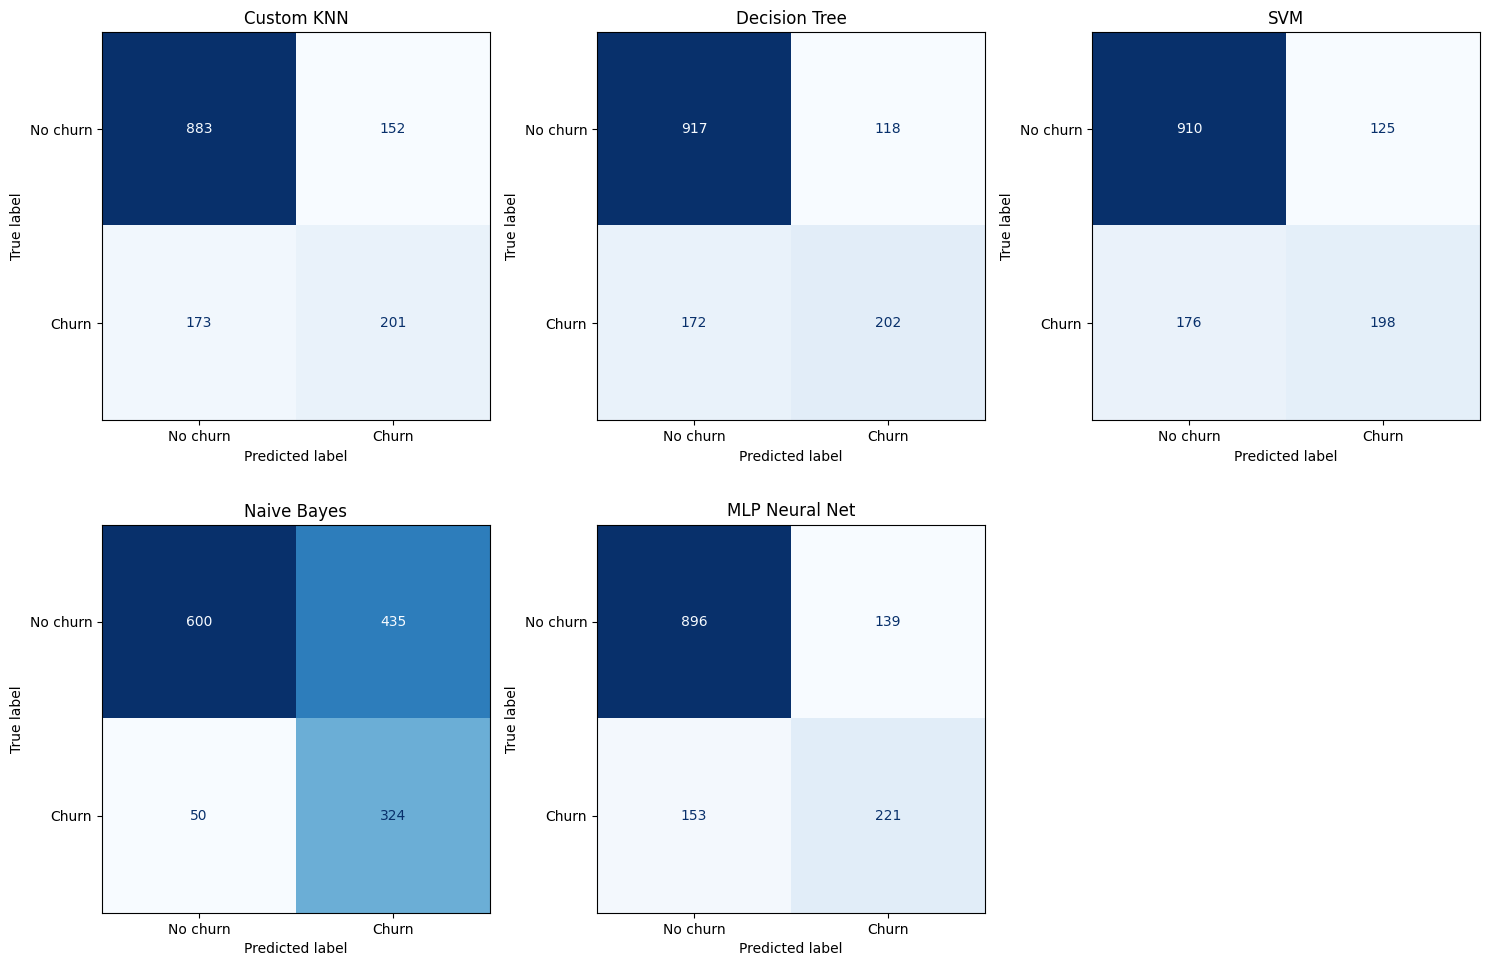

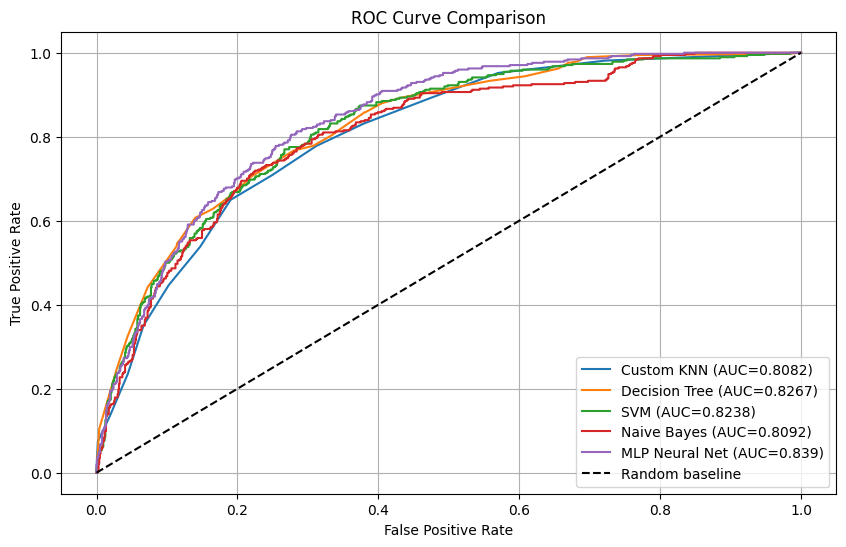

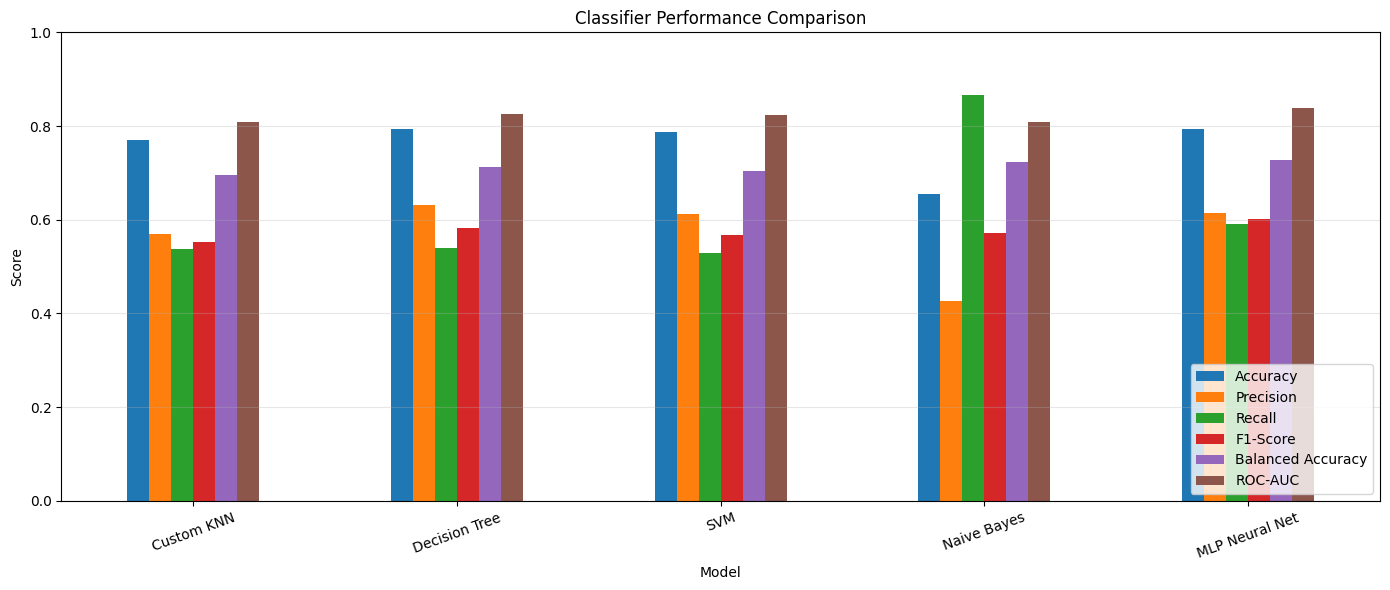

In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, matthews_corrcoef, log_loss
)

# Compare train/test accuracy and cross-validation accuracy.
for name, model in trained_models.items():
    train_accuracy = accuracy_score(y_train, model.predict(X_train_scaled))
    test_accuracy = accuracy_score(y_test, predictions[name])
    print(name, "train accuracy:", round(train_accuracy, 3),
          "test accuracy:", round(test_accuracy, 3))

for name, model in models.items():
    if name != "Custom KNN":
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv_strategy)
        print(name, "cross-validation accuracy:", round(scores.mean(), 3))

results = []
for name, preds in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "Specificity": round(specificity, 4),
        "F1-Score": round(f1_score(y_test, preds, zero_division=0), 4),
        "Balanced Accuracy": round(balanced_accuracy_score(y_test, preds), 4),
        "ROC-AUC": round(roc_auc_score(y_test, probabilities[name]), 4),
        "MCC": round(matthews_corrcoef(y_test, preds), 4),
        "Log Loss": round(log_loss(y_test, probabilities[name]), 4)
    })

df_results = pd.DataFrame(results)
print("=== CLASSIFIER EVALUATION COMPARISON ===")
print(df_results.to_string(index=False))

n_models = len(predictions)
n_columns = min(3, n_models)
n_rows = int(np.ceil(n_models / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(5 * n_columns, 5 * n_rows))
axes = np.atleast_1d(axes).ravel()
for i, (name, preds) in enumerate(predictions.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, preds),
        display_labels=["No churn", "Churn"]
    ).plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)
for axis in axes[n_models:]:
    axis.remove()
fig.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for name in predictions:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_value = df_results.loc[df_results["Model"] == name, "ROC-AUC"].iloc[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value})")
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

metrics_to_plot = [
    "Accuracy", "Precision", "Recall",
    "F1-Score", "Balanced Accuracy", "ROC-AUC"
]
df_results.set_index("Model")[metrics_to_plot].plot(
    kind="bar", figsize=(14, 6), ylim=(0, 1), rot=20
)
plt.title("Classifier Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [14]:
overfitting_results = []

for name, model in trained_models.items():
    train_accuracy = accuracy_score(y_train, model.predict(X_train_scaled))
    test_accuracy = accuracy_score(y_test, predictions[name])
    overfitting_results.append({
        "Model": name,
        "Training Accuracy": round(train_accuracy, 4),
        "Test Accuracy": round(test_accuracy, 4),
        "Accuracy Gap": round(train_accuracy - test_accuracy, 4)
    })

overfitting_df = pd.DataFrame(overfitting_results)
print("=== OVERFITTING ANALYSIS ===")
print(overfitting_df.to_string(index=False))

=== OVERFITTING ANALYSIS ===
         Model  Training Accuracy  Test Accuracy  Accuracy Gap
    Custom KNN             0.8126         0.7693        0.0432
 Decision Tree             0.8021         0.7942        0.0079
           SVM             0.8001         0.7864        0.0138
   Naive Bayes             0.6654         0.6558        0.0096
MLP Neural Net             0.8186         0.7928        0.0258


In [15]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

joblib.dump(
    {name: model for name, model in trained_models.items() if name != "Custom KNN"},
    artifacts_dir / "sklearn_models.joblib"
)
np.savez(
    artifacts_dir / "knn_data.npz",
    X_train=knn_scratch.X_train,
    y_train=knn_scratch.y_train
)

metadata = {
    "feature_columns": X.columns.tolist(),
    "target_column": "Churn",
    "knn_k": knn_scratch.k,
    "models": list(trained_models.keys())
}
with open(artifacts_dir / "metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

joblib.dump(scaler, artifacts_dir / "scaler.joblib")
df_results.to_csv(artifacts_dir / "metrics.csv", index=False)
overfitting_df.to_csv(artifacts_dir / "overfitting.csv", index=False)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(5 * n_columns, 5 * n_rows))
axes = np.atleast_1d(axes).ravel()
for i, (name, preds) in enumerate(predictions.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, preds),
        display_labels=["No churn", "Churn"]
    ).plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)
for axis in axes[n_models:]:
    axis.remove()
fig.tight_layout()
fig.savefig(artifacts_dir / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, axis = plt.subplots(figsize=(10, 6))
for name in predictions:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_value = df_results.loc[df_results["Model"] == name, "ROC-AUC"].iloc[0]
    axis.plot(fpr, tpr, label=f"{name} (AUC={auc_value})")
axis.plot([0, 1], [0, 1], "k--", label="Random baseline")
axis.set_xlabel("False Positive Rate")
axis.set_ylabel("True Positive Rate")
axis.set_title("ROC Curve Comparison")
axis.legend(loc="lower right")
axis.grid(True)
fig.tight_layout()
fig.savefig(artifacts_dir / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, axis = plt.subplots(figsize=(14, 6))
df_results.set_index("Model")[metrics_to_plot].plot(
    kind="bar", ylim=(0, 1), rot=20, ax=axis
)
axis.set_title("Classifier Performance Comparison")
axis.set_ylabel("Score")
axis.set_xlabel("Model")
axis.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(artifacts_dir / "metric_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Exported models, metadata, metrics, and plots to {artifacts_dir.resolve()}")

Exported models, metadata, metrics, and plots to /Users/rivakoirala/Documents/Data Mining/artifacts
